# Residue Environment Analysis (5 Å Shell)

**What this notebook does:**
- Uses **MDAnalysis** to analyse the dynamic neighbourhood (within 5 Å) of a target
  residue's Cα across all simulation frames
- For each simulation, it:
  1. Identifies every atom that ever appears within 5 Å of the target Cα
  2. Computes the **frequency** (% of frames) with which each neighbour atom appears
  3. Saves environment tables and frequency tables to CSV
- Builds a **heatmap** showing the frequency of each neighbouring atom per simulation

**How to adapt to a different residue:**
Change `RES` and `RESNUM` in the *Configuration* cell. The notebook uses these constants
everywhere, so no other edits are needed.

**Sections:**
1. Install & import libraries
2. Configuration (residue of interest, paths, chain boundary)
3. Helper functions: `get_dynamic_environment()`, `analyze_env_frequency()`
4. Discover simulation files
5. Compute and save environment tables per simulation
6. Load frequency tables & build heatmap matrix
7. Plot and save heatmap


In [69]:
# 1. Install required libraries (only needed once in a fresh environment)
!pip install MDAnalysis

In [1]:
# 2. Imports
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import MDAnalysis as mda

In [2]:
# 3. Configuration — adapt these values to your system

# ── Target residue ───────────────────────────────────────────────────────────
RES    = 'ASP'   # Three-letter residue name (e.g. 'ASN', 'ASP', 'GLU')
RESNUM = 25      # Residue number in the topology

# ── Atom-index boundary separating chain A from chain B ─────────────────────
# Atoms with index < CHAIN_BOUNDARY belong to chain A; >= to chain B.
CHAIN_BOUNDARY = 1536

# ── Environment cutoff (Å) ───────────────────────────────────────────────────
CUTOFF = 5.0

# ── Paths ────────────────────────────────────────────────────────────────────
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
OUTPUT_DIR = Path('/content/drive/MyDrive/M1_STAGE/Manips/Tables/')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Which chain to analyse ('chA' selects index 0:CHAIN_BOUNDARY,
#                             'chB' selects index CHAIN_BOUNDARY:) ──────────
TARGET_CHAIN = 'chB'

SIMULATION_NAMES = ['V1', 'V11', 'V12', 'V7', 'V8', 'V21']

os.chdir(ROOTDIR)

In [ ]:
# 4. Helper functions

def _get_chain_select(chain: str, boundary: int) -> str:
    """Return an MDAnalysis index range string for the requested chain."""
    if chain == 'chA':
        return f'index 0:{boundary}'
    return f'index {boundary}:{boundary * 2}'


def get_dynamic_environment(gro: str, xtc: str,
                             resnum: int = RESNUM,
                             chain: str = TARGET_CHAIN,
                             cutoff: float = CUTOFF) -> list:
    """
    Return the set of all atoms that appear within `cutoff` Å of the target
    residue Cα across the full trajectory.

    Returns
    -------
    List of (atom_name, resname, resnum, atom_index) tuples, sorted by index.
    """
    u = mda.Universe(gro, xtc)
    chain_sel = _get_chain_select(chain, CHAIN_BOUNDARY)
    target_CA = u.select_atoms(f'name CA and resnum {resnum} and {chain_sel}')

    env_atoms = set()
    for _ in u.trajectory:
        around = u.select_atoms(
            f'around {cutoff} group target', target=target_CA)
        for atm in around.atoms:
            env_atoms.add((atm.name, atm.resname, atm.resnum, atm.index))

    return sorted(env_atoms, key=lambda x: x[3])


def analyze_env_frequency(gro: str, xtc: str,
                           resnum: int = RESNUM,
                           chain: str = TARGET_CHAIN,
                           cutoff: float = CUTOFF) -> pd.DataFrame:
    """
    Compute the percentage of frames in which each atom appears within
    `cutoff` Å of the target residue Cα.

    Returns
    -------
    DataFrame with columns ['Residue', 'Frequency'], sorted descending by Frequency.
    """
    u = mda.Universe(gro, xtc)
    chain_sel = _get_chain_select(chain, CHAIN_BOUNDARY)
    target_CA = u.select_atoms(f'name CA and resnum {resnum} and {chain_sel}')

    atom_counts = {}
    n_frames = 0

    for _ in u.trajectory[::1]:
        n_frames += 1
        neighbours = (
            u.select_atoms(f'around {cutoff} group target', target=target_CA).residues
            - target_CA.residues
        )
        for atm in neighbours.atoms:
            key = f'{atm.index}_{atm.name}_{atm.resname}_{atm.resnum}'
            atom_counts[key] = atom_counts.get(key, 0) + 1

    freq_data = [
        {'Residue': k, 'Frequency': (v / n_frames) * 100}
        for k, v in atom_counts.items()
    ]
    return pd.DataFrame(freq_data).sort_values('Frequency', ascending=False)

In [4]:
# 5. Discover simulation file pairs (.gro + .xtc)
sim_files = []

for subdir, _, files in os.walk(ROOTDIR):
    gro_files = [f for f in files if f.endswith('.gro')]
    xtc_files = [f for f in files if f.endswith('.xtc')]
    for gro_name in gro_files:
        key = gro_name.replace('.gro', '')
        found_xtc = next((x for x in xtc_files if key in x), None)
        if found_xtc:
            sim_files.append((
                os.path.join(subdir, gro_name),
                os.path.join(subdir, found_xtc)
            ))

sim_files.sort()
print(f'Found {len(sim_files)} simulation pair(s).')

Found 6 simulation pair(s).


In [5]:
# 6. Compute environment tables and frequency tables for each simulation
for gro, xtc in sim_files:
    sim_name = os.path.basename(os.path.dirname(gro))
    print(f'Processing {sim_name} ...')

    # Environment (unique atoms ever within cutoff)
    env_df = pd.DataFrame(
        get_dynamic_environment(gro, xtc),
        columns=['atomname', 'resname', 'resid', 'atomic_index']
    ).sort_values('atomic_index').reset_index(drop=True)
    env_df.to_csv(OUTPUT_DIR / f'{sim_name}_{RES}{RESNUM}_{TARGET_CHAIN}_env_atoms.csv',
                  index=False)

    # Frequency table
    freq_df = analyze_env_frequency(gro, xtc)
    freq_df.to_csv(OUTPUT_DIR / f'{sim_name}_{RES}{RESNUM}_{TARGET_CHAIN}_env_atoms_frequency.csv',
                   index=False)

print('Done.')

Processing V1 ...


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


Processing V11 ...
Processing V12 ...
Processing V21 ...
Processing V7 ...
Processing V8 ...
Done.


In [6]:
# 7. Load frequency tables and prepare heatmap matrix

# 7.1. Load each simulation's frequency CSV
all_results = {}
for sim_name in SIMULATION_NAMES:
    freq_path = OUTPUT_DIR / f'{sim_name}_{RES}{RESNUM}_{TARGET_CHAIN}_env_atoms_frequency.csv'
    if not freq_path.exists():
        print(f'[WARN] {freq_path} not found — skipping.')
        continue

    df_sim = pd.read_csv(freq_path)
    # Filter: keep only Cα atoms; exclude the target residue's own Cα
    target_label = f'CA_{RES}_{RESNUM}'
    filtered = df_sim[
        df_sim['Residue'].apply(lambda x: 'CA' in x and not x.endswith(target_label))
    ].copy()

    # Build descriptive label (strip atom_index prefix that can vary across sims)
    rows = []
    for atom in filtered['Residue'].values:
        parts      = atom.split('_')
        atom_idx   = int(parts[0])
        atom_name  = parts[1]
        res_type   = parts[2]
        res_num    = parts[3]
        chain_lbl  = 'chA' if atom_idx < CHAIN_BOUNDARY else 'chB'
        desc_label = f'{atom_name}_{res_type}{res_num}_{chain_lbl}'
        rows.append({
            'Atom_Identifier': atom,
            'Frequency': float(filtered.loc[filtered['Residue'] == atom, 'Frequency'].iloc[0]),
            'Chain': chain_lbl,
            'Residue_Id': f'{res_type}{res_num}',
            'Descriptive_Label': desc_label
        })
    all_results[sim_name] = pd.DataFrame(rows)

In [7]:
# 7.2. Build heatmap matrix (simulations × residue descriptive labels)
atom_data_df = pd.concat(
    [df.assign(Simulation=name) for name, df in all_results.items()],
    ignore_index=True
)

all_residues = sorted(atom_data_df['Descriptive_Label'].unique())
heatmap_data = pd.DataFrame(0.0, index=SIMULATION_NAMES, columns=all_residues)

for sim_name, df_sim in all_results.items():
    merged = df_sim.groupby('Descriptive_Label')['Frequency'].max()
    for label, freq in merged.items():
        if label in heatmap_data.columns:
            heatmap_data.loc[sim_name, label] = freq

heatmap_data = heatmap_data.fillna(0.0)

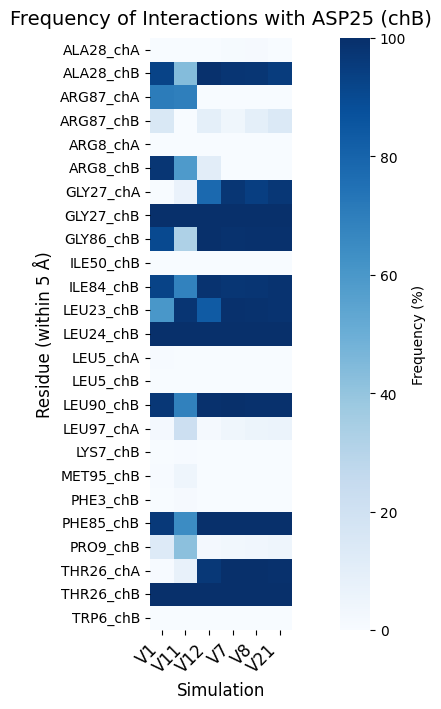

Heatmap saved to /content/drive/MyDrive/M1_STAGE/Manips/Figures/env_25_chB_heatmap.png


In [8]:
# 8. Plot heatmap
fig, ax = plt.subplots(figsize=(max(8, len(all_residues) * 0.4), max(4, len(SIMULATION_NAMES) * 1.2)))

y_labels = [lbl.replace('CA_', '') for lbl in heatmap_data.columns]

sns.heatmap(
    heatmap_data.T,
    annot=False,
    cmap='Blues',
    square=True,
    cbar_kws={'label': 'Frequency (%)'},
    ax=ax
)

ax.set_title(f'Frequency of Interactions with {RES}{RESNUM} ({TARGET_CHAIN})',
             fontsize=14, pad=10)
ax.set_xlabel('Simulation', fontsize=12)
ax.set_ylabel('Residue (within 5 Å)', fontsize=12)
ax.set_yticklabels(y_labels, rotation=0, fontsize=10)
ax.set_xticklabels(SIMULATION_NAMES, rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()

out_fig = OUTPUT_DIR.parent / f'Figures/env_{RESNUM}_{TARGET_CHAIN}_heatmap.png'
fig.savefig(out_fig, bbox_inches='tight', dpi=300)
print(f'Heatmap saved to {out_fig}')